# IDRA Final Capstone Project
## Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals Using Machine Learning

**Project type:** Regression  
**Target:** `lengthofstay`  
**Dataset:** `P_1_LengthOfStay(1).csv`

This notebook implements the IDRA Project 1 workflow:
1. Dataset understanding
2. Data quality audit
3. Data cleaning
4. Target-leakage checks
5. Feature engineering and preprocessing
6. Exploratory Data Analysis
7. Statistical analysis
8. Regression modelling
9. Model evaluation
10. Findings and conclusions

> **Important:** Results are generated directly from the supplied dataset. The `discharged` field is checked for target leakage and excluded from the predictive feature matrix because it is post-outcome information.


## 1. Import Libraries and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = Path("P_1_LengthOfStay(1).csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/P_1_LengthOfStay(1).csv")

print("Data path:", DATA_PATH)


Data path: P_1_LengthOfStay(1).csv


## 2. Load Dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head())


Shape: (61680, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


## 3. Dataset Understanding

In [3]:
print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])
print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nUnique values:")
display(df_raw.nunique().sort_values().to_frame("unique_values"))

print("\nDescriptive statistics:")
display(df_raw.describe(include="all").T)


Rows: 61680
Columns: 28

Data types:


,dtype
eid,int64
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64



Unique values:


,unique_values
gender,2
irondef,2
asthma,2
dialysisrenalendstage,2
pneum,2
depress,2
psychologicaldisordermajor,2
substancedependence,2
fibrosisandother,2
malnutrition,2



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
eid,61680.0,NaN,NaN,NaN,30840.5,17805.626639,1.0,15420.75,30840.5,46260.25,61680.0
vdate,61680,367,3/25/2012,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rcount,61680,6,0,33976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,61680,2,F,35704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dialysisrenalendstage,61680.0,NaN,NaN,NaN,0.036365,0.187198,0.0,0.0,0.0,0.0,1.0
asthma,61680.0,NaN,NaN,NaN,0.034679,0.182967,0.0,0.0,0.0,0.0,1.0
irondef,61680.0,NaN,NaN,NaN,0.095542,0.293964,0.0,0.0,0.0,0.0,1.0
pneum,61680.0,NaN,NaN,NaN,0.039559,0.194922,0.0,0.0,0.0,0.0,1.0
substancedependence,61680.0,NaN,NaN,NaN,0.062954,0.242882,0.0,0.0,0.0,0.0,1.0
psychologicaldisordermajor,61680.0,NaN,NaN,NaN,0.236106,0.424691,0.0,0.0,0.0,0.0,1.0


## 4. Data Quality Audit

In [4]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)

quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct,
    "dtype": df_raw.dtypes.astype(str)
})

print("Total duplicate rows:", df_raw.duplicated().sum())
display(quality_report)

print("\nCategorical value checks:")
for col in df_raw.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    display(df_raw[col].value_counts(dropna=False).head(20))


Total duplicate rows: 0


,missing_count,missing_percent,dtype
eid,0,0.0,int64
vdate,0,0.0,object
rcount,0,0.0,object
gender,0,0.0,object
dialysisrenalendstage,0,0.0,int64
asthma,0,0.0,int64
irondef,0,0.0,int64
pneum,0,0.0,int64
substancedependence,0,0.0,int64
psychologicaldisordermajor,0,0.0,int64



Categorical value checks:

vdate:


vdate
3/25/2012     210
6/14/2012     208
11/11/2012    208
10/3/2012     206
12/4/2012     204
2/22/2012     198
9/27/2012     198
9/5/2012      198
7/7/2012      196
5/7/2012      195
11/28/2012    194
4/29/2012     194
9/18/2012     194
6/3/2012      193
10/11/2012    193
6/12/2012     193
6/4/2012      193
12/15/2012    192
6/19/2012     192
11/24/2012    192
Name: count, dtype: int64


rcount:


...

gender
F    35704
M    25976
Name: count, dtype: int64


discharged:


discharged
2/16/2012     207
2/10/2012     201
3/9/2012      199
10/25/2012    198
6/6/2012      197
9/17/2012     195
6/19/2012     193
2/14/2012     193
5/22/2012     191
10/6/2012     191
3/16/2012     191
8/23/2012     191
12/20/2012    191
7/25/2012     191
2/3/2012      190
5/5/2012      190
7/28/2012     190
2/7/2012      189
7/23/2012     189
2/22/2012     188
Name: count, dtype: int64


facid:


facid
E    18880
A    18657
B    18470
C     2899
D     2774
Name: count, dtype: int64

## 5. Date and Target Validation

The target is `lengthofstay`.

The dataset contains both `vdate` and `discharged`. Because discharge information occurs after the hospitalization, `discharged` must not be used as a predictive feature for an admission-time prediction task.

We also validate whether:

`discharged - vdate == lengthofstay`

If this equality holds, `discharged` is a direct target-leakage variable and will be excluded.


In [5]:
df = df_raw.copy()

df["vdate_parsed"] = pd.to_datetime(df["vdate"], errors="coerce")
df["discharged_parsed"] = pd.to_datetime(df["discharged"], errors="coerce")

date_difference = (df["discharged_parsed"] - df["vdate_parsed"]).dt.days

leakage_check = pd.DataFrame({
    "lengthofstay": df["lengthofstay"],
    "date_difference_days": date_difference
})

print("Invalid visit dates:", df["vdate_parsed"].isna().sum())
print("Invalid discharge dates:", df["discharged_parsed"].isna().sum())
print("Rows where discharge - visit != lengthofstay:",
      (date_difference != df["lengthofstay"]).sum())
print("Rows checked:", len(df))

display(leakage_check.head(10))


Invalid visit dates: 0
Invalid discharge dates: 0
Rows where discharge - visit != lengthofstay: 0
Rows checked: 61680


,lengthofstay,date_difference_days
0,3,3
1,7,7
2,3,3
3,1,1
4,4,4
5,6,6
6,6,6
7,3,3
8,3,3
9,2,2


## 6. Data Cleaning and Feature Engineering

In [6]:
# Work on a clean modelling dataframe
df_clean = df.copy()

# Standardize date-derived information known at admission.
df_clean["admission_year"] = df_clean["vdate_parsed"].dt.year
df_clean["admission_month"] = df_clean["vdate_parsed"].dt.month
df_clean["admission_dayofweek"] = df_clean["vdate_parsed"].dt.dayofweek
df_clean["admission_quarter"] = df_clean["vdate_parsed"].dt.quarter

# Keep the original raw dates out of the ML feature matrix.
# `discharged` is excluded because it is post-outcome information.
# `eid` is an identifier rather than a meaningful predictor.
drop_for_model = [
    "eid",
    "vdate",
    "discharged",
    "vdate_parsed",
    "discharged_parsed",
    "lengthofstay"
]

df_model = df_clean.drop(columns=drop_for_model)

print("Clean modelling dataset shape:", df_model.shape)
display(df_model.head())


Clean modelling dataset shape: (61680, 28)


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,facid,admission_year,admission_month,admission_dayofweek,admission_quarter
0,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,B,2012,8,2,3
1,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,A,2012,5,5,2
2,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,B,2012,9,5,3
3,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,A,2012,8,3,3
4,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,E,2012,12,3,4


## 7. Target Analysis

Target summary:


count    61680.000000
mean         3.999368
std          2.357744
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         17.000000
Name: lengthofstay, dtype: float64


Target value counts:


,count
lengthofstay,
1,11106
2,7947
3,9805
4,9111
5,7589
6,6411
7,4483
8,2837
9,1333


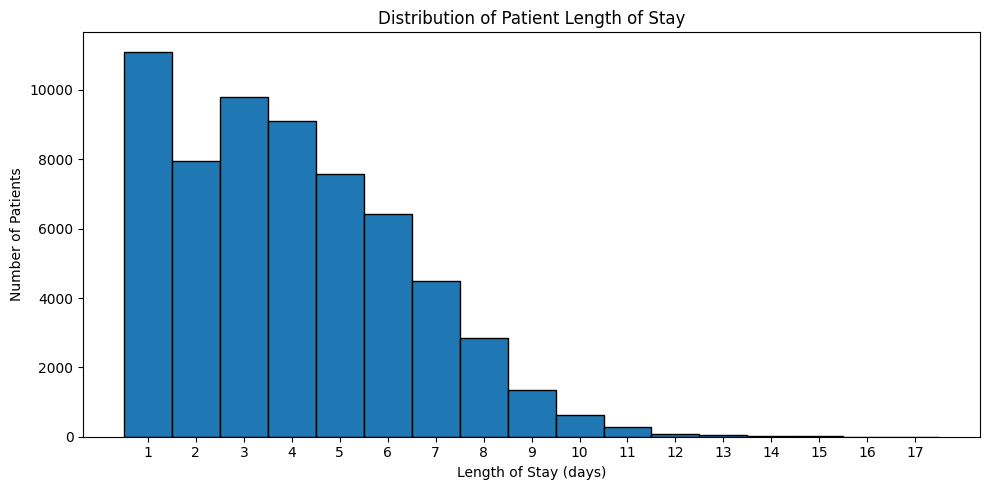

In [7]:
target = df_clean["lengthofstay"]

print("Target summary:")
display(target.describe())

print("\nTarget value counts:")
display(target.value_counts().sort_index().to_frame("count"))

plt.figure(figsize=(10, 5))
plt.hist(target, bins=np.arange(0.5, 17.6, 1), edgecolor="black")
plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.xticks(range(1, 18))
plt.tight_layout()
plt.show()


## 8. Exploratory Data Analysis

,count,mean,median,std
facid,,,,
E,18880,5.149364,5.0,2.069311
C,2899,4.915143,5.0,2.051538
D,2774,4.820836,4.0,2.108656
B,18470,3.285490,3.0,2.250052
A,18657,3.277912,3.0,2.263752


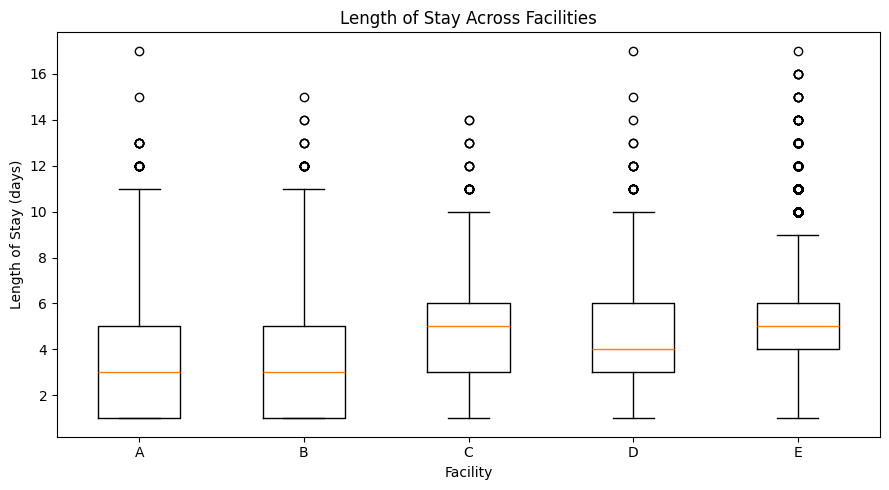

In [8]:
# 8.1 Length of stay by admission facility
facility_summary = (
    df_clean.groupby("facid")["lengthofstay"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
display(facility_summary)

plt.figure(figsize=(9, 5))
groups = [g["lengthofstay"].values for _, g in df_clean.groupby("facid", sort=True)]
labels = sorted(df_clean["facid"].dropna().unique())
plt.boxplot(groups, labels=labels)
plt.title("Length of Stay Across Facilities")
plt.xlabel("Facility")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.show()


,count,mean,median,std
rcount,,,,
0,33976,2.723216,3.0,1.652497
1,9268,3.706949,4.0,1.644191
2,6152,5.271131,5.0,1.294396
3,4961,6.270510,6.0,1.318829
4,4273,7.253920,7.0,1.329714
5+,3050,8.284918,8.0,1.357100


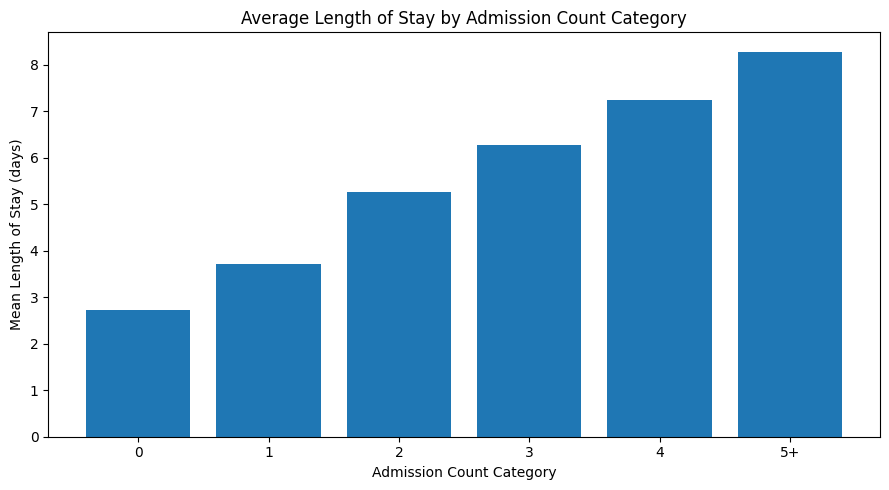

In [9]:
# 8.2 Length of stay across rcount categories
rcount_summary = (
    df_clean.groupby("rcount")["lengthofstay"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
display(rcount_summary)

plt.figure(figsize=(9, 5))
plot_data = rcount_summary.reset_index()
plt.bar(plot_data["rcount"].astype(str), plot_data["mean"])
plt.title("Average Length of Stay by Admission Count Category")
plt.xlabel("Admission Count Category")
plt.ylabel("Mean Length of Stay (days)")
plt.tight_layout()
plt.show()


,count,mean,median,std
gender,,,,
F,35704,3.866962,4.0,2.339585
M,25976,4.181360,4.0,2.370484


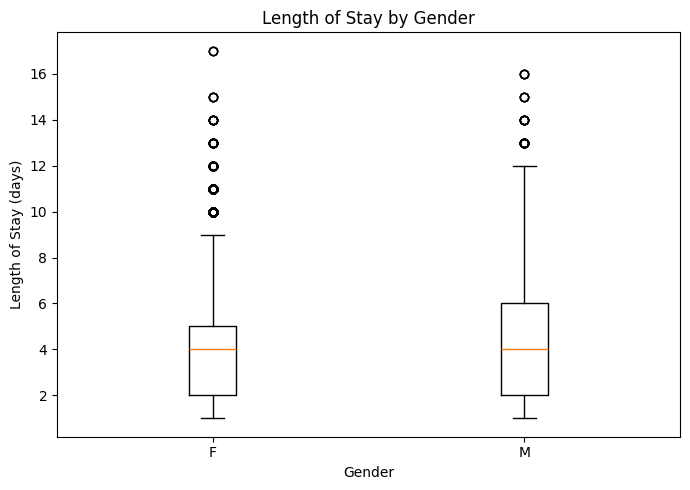

In [10]:
# 8.3 Gender comparison
gender_summary = (
    df_clean.groupby("gender")["lengthofstay"]
    .agg(["count", "mean", "median", "std"])
)
display(gender_summary)

plt.figure(figsize=(7, 5))
groups = [g["lengthofstay"].values for _, g in df_clean.groupby("gender", sort=True)]
labels = sorted(df_clean["gender"].dropna().unique())
plt.boxplot(groups, labels=labels)
plt.title("Length of Stay by Gender")
plt.xlabel("Gender")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.show()


,correlation_with_lengthofstay
psychologicaldisordermajor,0.281010
hemo,0.218141
irondef,0.194290
psychother,0.193905
malnutrition,0.170695
dialysisrenalendstage,0.170312
bloodureanitro,0.151434
substancedependence,0.149642
pneum,0.135205
depress,0.122543


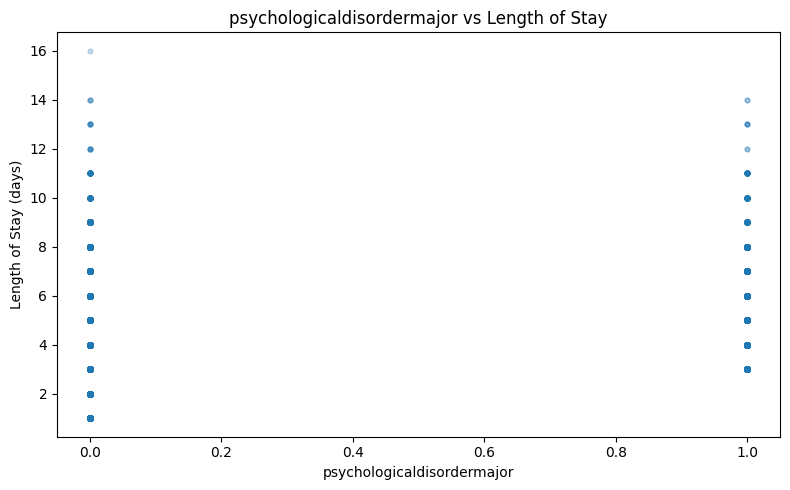

In [11]:
# 8.4 Medical/clinical variables vs target
medical_cols = [
    "dialysisrenalendstage", "asthma", "irondef", "pneum",
    "substancedependence", "psychologicaldisordermajor", "depress",
    "psychother", "fibrosisandother", "malnutrition", "hemo"
]
clinical_cols = [
    "hematocrit", "neutrophils", "sodium", "glucose",
    "bloodureanitro", "creatinine", "bmi", "pulse",
    "respiration", "secondarydiagnosisnonicd9"
]

correlation_cols = medical_cols + clinical_cols + ["lengthofstay"]

corr_with_target = (
    df_clean[correlation_cols]
    .corr(numeric_only=True)["lengthofstay"]
    .drop("lengthofstay")
    .sort_values(key=np.abs, ascending=False)
)

display(corr_with_target.to_frame("correlation_with_lengthofstay"))

top_feature = corr_with_target.index[0]

plt.figure(figsize=(8, 5))
sample = df_clean.sample(min(10000, len(df_clean)), random_state=RANDOM_STATE)
plt.scatter(sample[top_feature], sample["lengthofstay"], alpha=0.25, s=12)
plt.title(f"{top_feature} vs Length of Stay")
plt.xlabel(top_feature)
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.show()


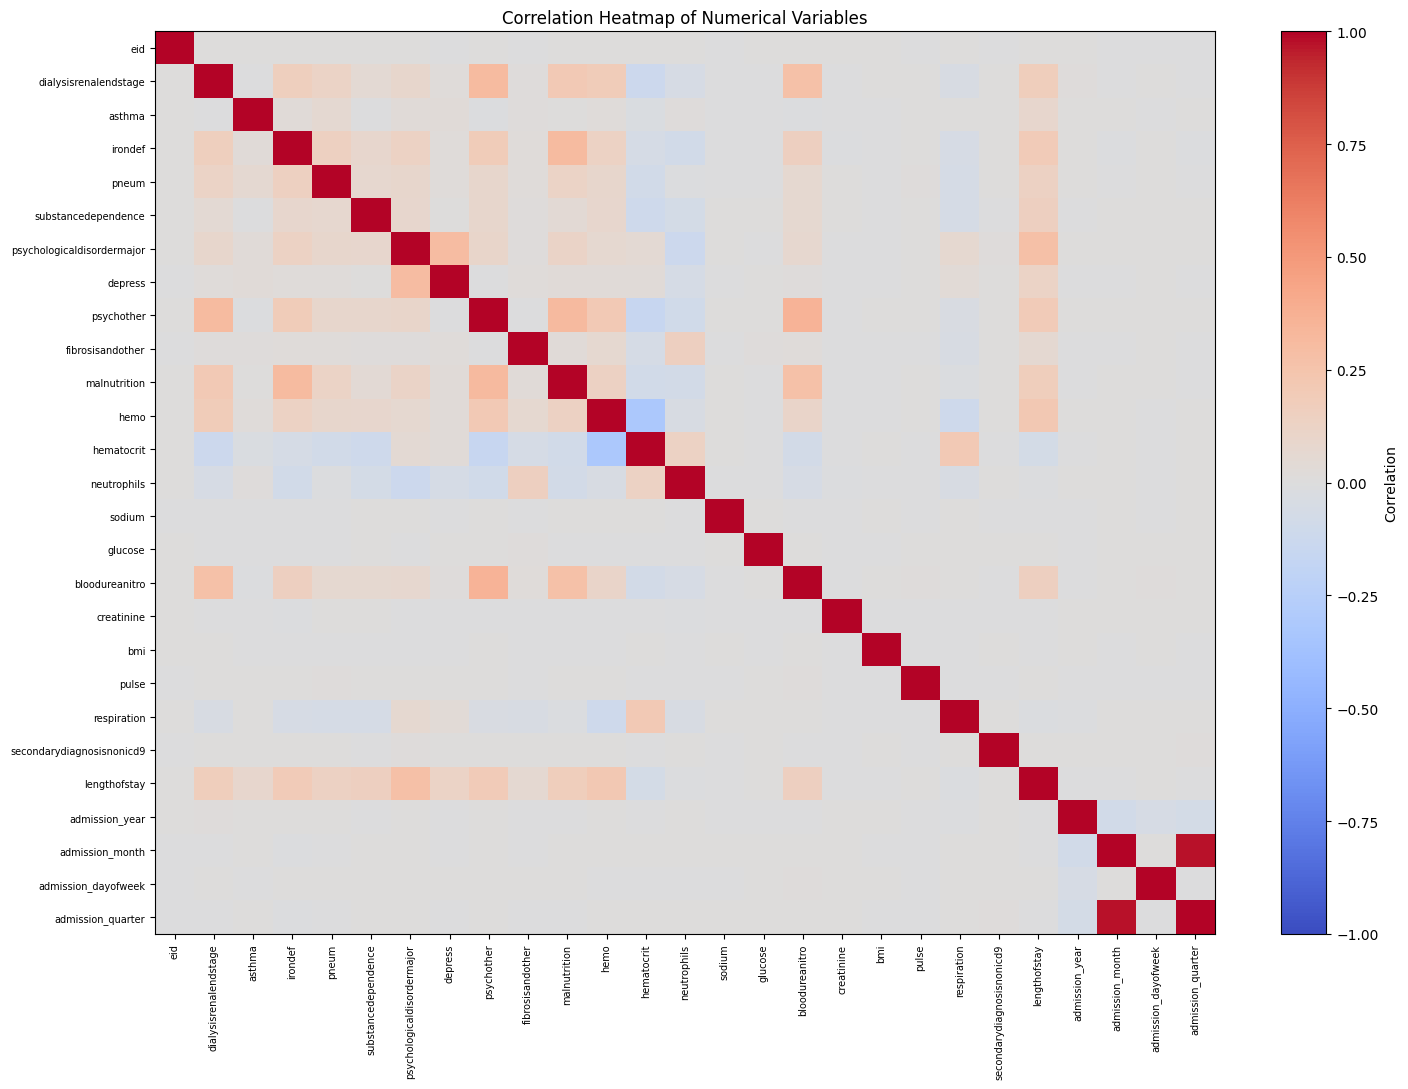

In [12]:
# 8.5 Correlation heatmap
numeric_cols = df_clean.select_dtypes(include=np.number).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(15, 11))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=7)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


## 9. Statistical Analysis

In [13]:
key_numeric = [
    "lengthofstay", "hematocrit", "neutrophils", "sodium",
    "glucose", "bloodureanitro", "creatinine", "bmi",
    "pulse", "respiration", "secondarydiagnosisnonicd9"
]

stats_table = pd.DataFrame({
    "mean": df_clean[key_numeric].mean(),
    "median": df_clean[key_numeric].median(),
    "mode": df_clean[key_numeric].mode().iloc[0],
    "std": df_clean[key_numeric].std(),
    "variance": df_clean[key_numeric].var(),
    "IQR": df_clean[key_numeric].quantile(0.75) - df_clean[key_numeric].quantile(0.25),
    "min": df_clean[key_numeric].min(),
    "max": df_clean[key_numeric].max()
})

display(stats_table)


,mean,median,mode,std,variance,IQR,min,max
lengthofstay,3.999368,4.000000,1.000000,2.357744,5.558958,4.000000,1.000000,17.000000
hematocrit,11.966872,11.900000,11.900000,2.038621,4.155977,2.000000,4.400000,24.100000
neutrophils,10.196406,9.400000,9.400000,5.271263,27.786214,3.800000,0.100000,245.900000
sodium,137.896793,137.900871,133.816514,3.000727,9.004362,4.040305,124.912632,151.387283
glucose,142.052746,142.249278,129.720211,29.923142,895.394439,40.334210,-1.005927,268.571156
bloodureanitro,14.113017,12.000000,12.000000,12.749797,162.557322,3.000000,1.000000,682.500000
creatinine,1.099037,1.098405,0.896881,0.200437,0.040175,0.270540,0.219770,2.035202
bmi,29.803679,29.804745,28.303062,2.000390,4.001560,2.696039,22.037695,38.935293
pulse,73.422568,73.000000,71.000000,11.651837,135.765304,15.000000,21.000000,126.000000
respiration,6.492793,6.500000,6.500000,0.572551,0.327815,0.000000,0.200000,10.000000


## 10. Outlier Assessment

In [14]:
def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append([col, q1, q3, iqr, lower, upper, count, count / len(dataframe) * 100])
    return pd.DataFrame(
        rows,
        columns=["variable", "Q1", "Q3", "IQR", "lower_bound", "upper_bound",
                 "outlier_count", "outlier_percent"]
    ).sort_values("outlier_count", ascending=False)

outlier_report = iqr_outlier_summary(df_clean, key_numeric)
display(outlier_report)


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
9,respiration,6.500000,6.500000,0.000000,6.500000,6.500000,21856,35.434501
5,bloodureanitro,11.000000,14.000000,3.000000,6.500000,18.500000,12043,19.524968
2,neutrophils,7.700000,11.500000,3.800000,2.000000,17.200000,4071,6.600195
1,hematocrit,10.900000,12.900000,2.000000,7.900000,15.900000,3497,5.669585
10,secondarydiagnosisnonicd9,1.000000,3.000000,2.000000,-2.000000,6.000000,3126,5.068093
8,pulse,66.000000,81.000000,15.000000,43.500000,103.500000,658,1.066796
3,sodium,135.874040,139.914345,4.040305,129.813582,145.974804,464,0.752270
4,glucose,121.873358,162.207568,40.334210,61.372043,222.708882,441,0.714981
7,bmi,28.456682,31.152721,2.696039,24.412624,35.196780,420,0.680934
6,creatinine,0.964564,1.235104,0.270540,0.558754,1.640915,411,0.666342


## 11. Train-Test Split and Preprocessing

The target is separated before preprocessing.

Features that directly reveal the outcome are excluded:
- `discharged`
- `lengthofstay`

The identifier `eid` is also excluded.

Categorical variables are one-hot encoded. Numerical variables are imputed with the median and standardized. The preprocessing pipeline is fitted only on the training data to prevent data leakage.


In [15]:
X = df_model.copy()
y = df_clean["lengthofstay"].copy()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Categorical features: ['rcount', 'gender', 'facid']
Numerical features: ['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'admission_year', 'admission_month', 'admission_dayofweek', 'admission_quarter']
Training rows: 49344
Testing rows: 12336


## 12. Model Development

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_leaf=10
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    )
}

trained_models = {}
results = []

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    trained_models[name] = pipe

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results).sort_values("Test RMSE")
display(results_df)


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Random Forest,0.192493,0.417922,0.320686,0.680001,0.981559,0.915719
1,Decision Tree,0.624854,0.688205,0.828340,0.938335,0.876965,0.839518
0,Linear Regression,0.878846,0.865852,1.149607,1.137175,0.763020,0.764298


## 13. Model Evaluation

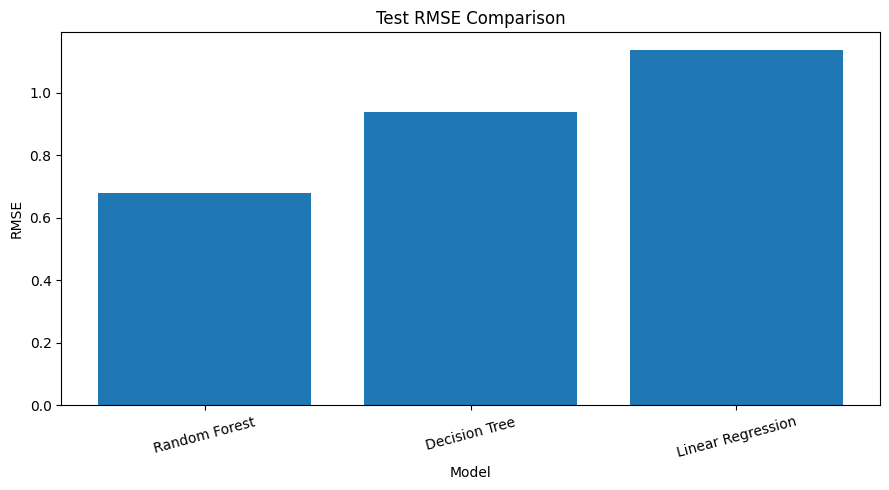

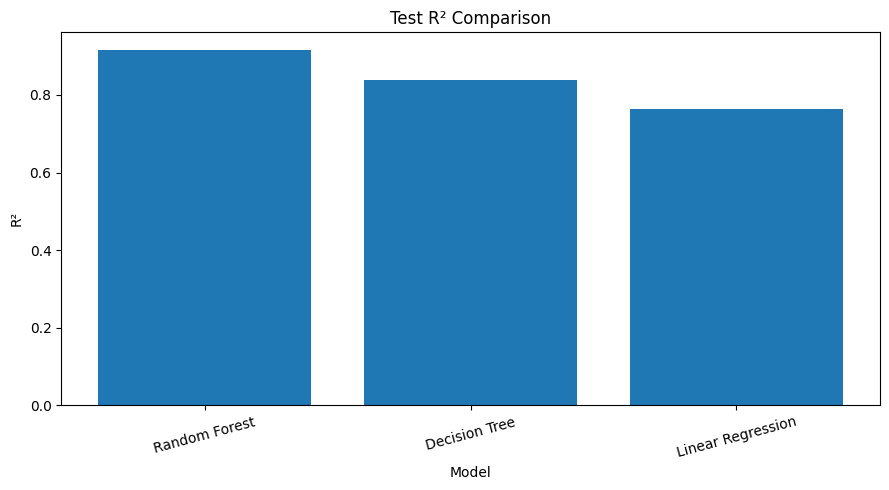

In [17]:
# Visual comparison of test RMSE
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Test RMSE"])
plt.title("Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Visual comparison of test R²
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Test R2"])
plt.title("Test R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Selected model for detailed error analysis: Random Forest


,Actual,Predicted,Residual
0,6,6.160857,-0.160857
1,7,7.257500,-0.257500
2,4,4.191262,-0.191262
3,1,1.000000,0.000000
4,4,4.508131,-0.508131
5,3,3.059583,-0.059583
6,5,4.133599,0.866401
7,8,7.621429,0.378571
8,1,1.000000,0.000000
9,6,5.041119,0.958881


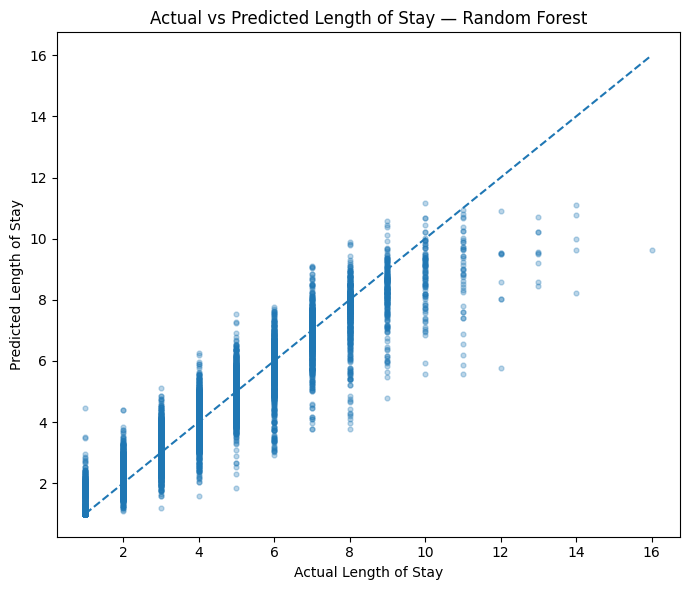

In [18]:
# Select the model using lowest test RMSE as the primary regression criterion.
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

evaluation = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions,
    "Residual": y_test.values - best_predictions
})

print("Selected model for detailed error analysis:", best_model_name)
display(evaluation.head(20))

plt.figure(figsize=(7, 6))
sample_eval = evaluation.sample(min(10000, len(evaluation)), random_state=RANDOM_STATE)
plt.scatter(sample_eval["Actual"], sample_eval["Predicted"], alpha=0.30, s=12)
min_val = min(evaluation["Actual"].min(), evaluation["Predicted"].min())
max_val = max(evaluation["Actual"].max(), evaluation["Predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Actual vs Predicted Length of Stay — {best_model_name}")
plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.tight_layout()
plt.show()


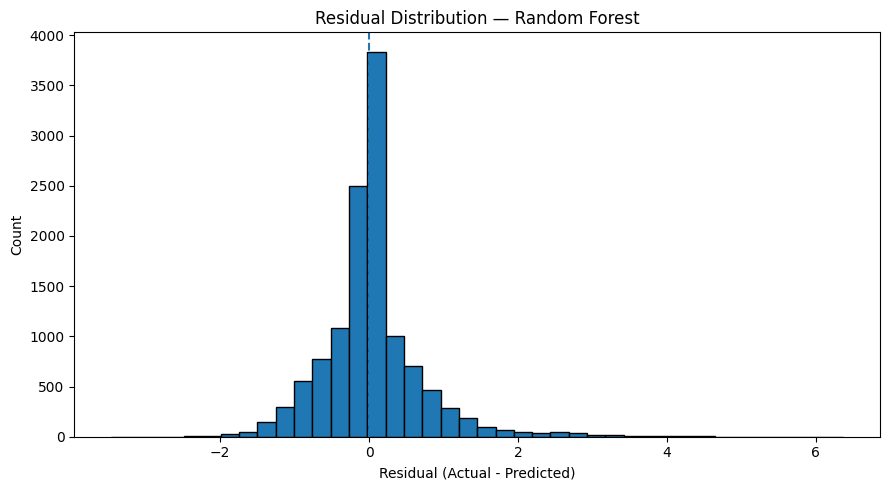

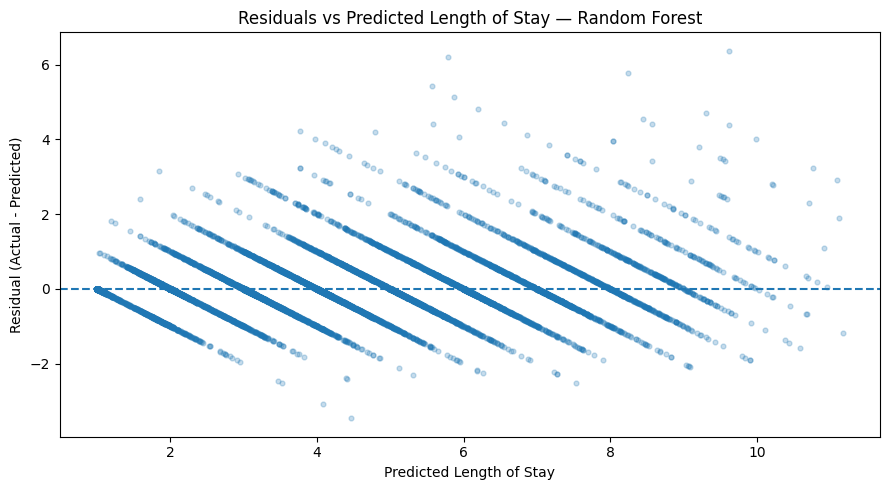

Detailed evaluation:
MAE : 0.4179220672065091
MSE : 0.4624013887908181
RMSE: 0.6800010211689524
R²  : 0.9157191875871464


In [19]:
# Residual distribution
plt.figure(figsize=(9, 5))
plt.hist(evaluation["Residual"], bins=40, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Residuals versus predicted values
plt.figure(figsize=(9, 5))
plt.scatter(evaluation["Predicted"], evaluation["Residual"], alpha=0.25, s=12)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Length of Stay — {best_model_name}")
plt.xlabel("Predicted Length of Stay")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

print("Detailed evaluation:")
print("MAE :", mean_absolute_error(y_test, best_predictions))
print("MSE :", mean_squared_error(y_test, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_predictions)))
print("R²  :", r2_score(y_test, best_predictions))


## 14. Findings Generator

In [20]:
print("DATASET")
print(f"- Observations: {len(df_clean):,}")
print(f"- Variables: {df_raw.shape[1]}")
print(f"- Missing values: {int(df_raw.isna().sum().sum())}")
print(f"- Duplicate rows: {int(df_raw.duplicated().sum())}")
print(f"- Target mean: {target.mean():.3f}")
print(f"- Target median: {target.median():.3f}")

print("\nTARGET LEAKAGE")
print(f"- Rows checked for discharge-date equality: {len(df_clean):,}")
print(f"- Mismatches between discharge-vdate and target: {(date_difference != df_clean['lengthofstay']).sum():,}")
print("- `discharged` is excluded from prediction features.")

print("\nMODEL RESULTS")
display(results_df)

print("\nTOP SIMPLE NUMERICAL CORRELATIONS WITH TARGET")
display(corr_with_target.head(10).to_frame("correlation"))


DATASET
- Observations: 61,680
- Variables: 28
- Missing values: 0
- Duplicate rows: 0
- Target mean: 3.999
- Target median: 4.000

TARGET LEAKAGE
- Rows checked for discharge-date equality: 61,680
- Mismatches between discharge-vdate and target: 0
- `discharged` is excluded from prediction features.

MODEL RESULTS


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Random Forest,0.192493,0.417922,0.320686,0.680001,0.981559,0.915719
1,Decision Tree,0.624854,0.688205,0.828340,0.938335,0.876965,0.839518
0,Linear Regression,0.878846,0.865852,1.149607,1.137175,0.763020,0.764298



TOP SIMPLE NUMERICAL CORRELATIONS WITH TARGET


,correlation
psychologicaldisordermajor,0.281010
hemo,0.218141
irondef,0.194290
psychother,0.193905
malnutrition,0.170695
dialysisrenalendstage,0.170312
bloodureanitro,0.151434
substancedependence,0.149642
pneum,0.135205
depress,0.122543


## 15. Interpretation Notes for the Final Report

When writing the final report:

- Treat EDA relationships as associations, not causal effects.
- Explain why `discharged` was excluded as a leakage variable.
- Report the actual model metrics generated above.
- Compare training and testing performance to discuss overfitting/underfitting.
- Explain MAE, RMSE and R² in the context of predicting hospital stay duration.
- Base recommendations only on findings supported by the completed analysis.
- Do not claim that the model is clinically validated or suitable for deployment without external validation.


## 16. Export Key Results

The following files are written to `capstone_outputs/` when the notebook is run:
- `model_results.csv`
- `data_quality_report.csv`
- `descriptive_statistics.csv`
- `facility_summary.csv`
- `rcount_summary.csv`
- `target_correlations.csv`

The notebook uses a fixed random seed (`42`) and an 80/20 train-test split so the reported results can be reproduced with the same software versions and dataset.


In [21]:
OUTPUT_DIR = Path("capstone_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

results_df.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
quality_report.to_csv(OUTPUT_DIR / "data_quality_report.csv")
stats_table.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
facility_summary.to_csv(OUTPUT_DIR / "facility_summary.csv")
rcount_summary.to_csv(OUTPUT_DIR / "rcount_summary.csv")
corr_with_target.to_csv(OUTPUT_DIR / "target_correlations.csv")

print("Saved key result tables to:", OUTPUT_DIR.resolve())


Saved key result tables to: /mnt/data/capstone_outputs
